### Load Necessary Packages

In [278]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem import SnowballStemmer

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, precision_score

import re, warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

In [279]:
# Uncomment and run once:
# !pip install bertopic datasets sentence-transformers umap-learn hdbscan plotly

# Verify installation
import bertopic
print(f"✅ BERTopic version: {bertopic.__version__}")

✅ BERTopic version: 0.17.4


### Load Data & EDA

In [280]:
data = pd.read_csv("news_AP.csv")
data

,title,topic
0,Terminally ill Connecticut woman ends her life...,Healthcare
1,King Charles III will have a prostate operatio...,Healthcare
2,Community health centers serve 1 in 11 America...,Healthcare
3,Washington state reaches a nearly $150 million...,Healthcare
4,Community health centers serve 1 in 11 America...,Healthcare
...,...,...
194,No joke: Feds discourage humorous electronic m...,Transportation
195,A timeline of key moments leading to Japan pla...,Transportation
196,Federal officials order grounding of some Boei...,Transportation
197,What you should know if you're about to fly on...,Transportation


In [281]:
title = data['title'].tolist()
topic = data['topic'].tolist()

In [282]:
data['topic'].unique()

array(['Healthcare', 'Sports - Football', 'Animals', 'Transportation'],
      dtype=object)

### EDA

In [283]:
print(f"Sampled dataset size: {len(data):,} documents")
print("\nTopic distribution:")
print(data["topic"].value_counts())

Sampled dataset size: 199 documents

Topic distribution:
topic
Sports - Football    81
Animals              48
Transportation       42
Healthcare           28
Name: count, dtype: int64


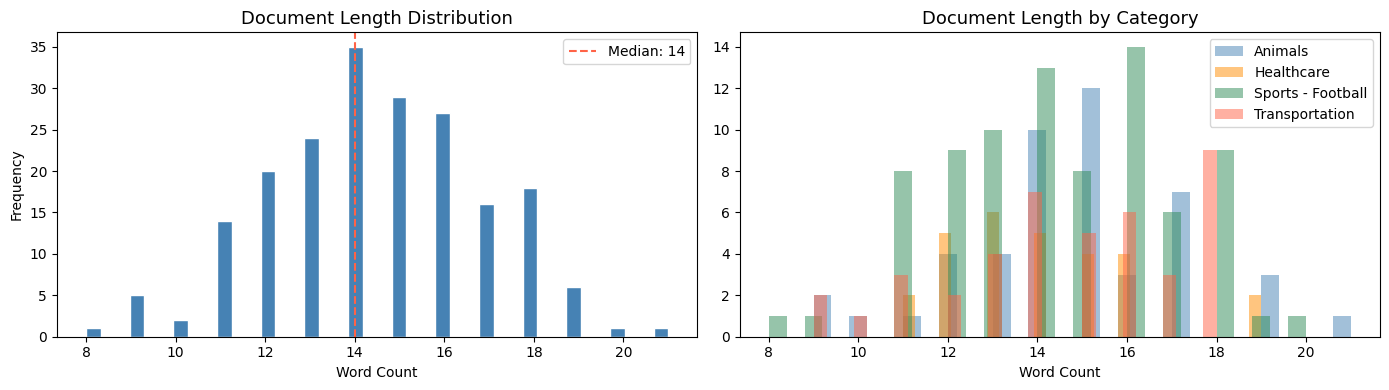

       word_count
count       199.0
mean         14.5
std           2.4
min           8.0
25%          13.0
50%          14.0
75%          16.0
max          21.0


In [284]:
# ── Document length distribution ──────────────────────────────────────────
data["word_count"] = data["title"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall histogram
axes[0].hist(data["word_count"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Document Length Distribution", fontsize=13)
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(data["word_count"].median(), color="tomato",
                linestyle="--", label=f'Median: {data["word_count"].median():.0f}')
axes[0].legend()

# By category
colors = ["steelblue", "darkorange", "seagreen", "tomato"]
for i, (cat, grp) in enumerate(data.groupby("topic")):
    axes[1].hist(grp["word_count"], bins=30, alpha=0.5, label=cat, color=colors[i])
axes[1].set_title("Document Length by Category", fontsize=13)
axes[1].set_xlabel("Word Count")
axes[1].legend()

plt.tight_layout()
plt.show()

print(data[["word_count"]].describe().round(1))

### Create Stop Words

In [285]:
# !pip install scikit-learn nltk gensim numpy pandas

# Try to load NLTK stopwords; fall back to a small built-in list if download fails
try:
    nltk.download('stopwords', quiet=True)
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words('english'))
except Exception:
    STOP_WORDS = {'a','an','the','and','or','but','if','of','at','by','for','with',
                  'about','to','from','in','on','is','are','was','were','be','been',
                  
                  'being','have','has','had','do','does','did','this','that','these',
                  'those','i','you','he','she','it','we','they','them','their','our',
                  'my','your','his','her','its'}

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

stop_words = STOP_WORDS
print(f'Using {len(stop_words)} English stop words.')

# remove non-english words that appear in data
# included also due to frequency
extra_words = {'also', 'περὶ', 'σπέρμα', 'τηθύς',
               'τραχεῖα', 'φυτά', 'φυτόν',
                'φυτῶν', 'המלח', 'ים', 'מעבדות', 'פרמייר', 
                'ἀγγεῖον', 'ἀρτηρία', 'ストーンオーシャン',
                '達爾膚生醫科技', '대우조선해양', '빅오션', '케이뷰티','한화오션'
}

stop_words.update(extra_words)
print(f'Using {len(stop_words)} English stop words.')

stop_words.remove('σπέρμα')
print(f'Using {len(stop_words)} English stop words.')

Using 198 English stop words.
Using 218 English stop words.
Using 217 English stop words.


In [286]:
tokenizer = CountVectorizer().build_tokenizer()
stemmer = SnowballStemmer('english')

### Preprocess Data for TF-IDF Vectorization

In [287]:
def preprocess(text):
    tokens = tokenizer(text)  # tokenize
    tokens = [stemmer.stem(t) for t in tokens] # stem
    tokens = [t for t in tokens if t not in stop_words]  # drop stop words
    return tokens

processed = [preprocess(d) for d in title]
for i, p in enumerate(processed, 1):
    print(f'Article{i}: {p}')

Article1: ['termin', 'ill', 'connecticut', 'woman', 'end', 'life', 'term', 'vermont']
Article2: ['king', 'charl', 'iii', 'prostat', 'oper', 'next', 'week', 'kate', 'recov', 'abdomin', 'surgeri']
Article3: ['communiti', 'health', 'center', 'serv', '11', 'american', 'safeti', 'net', 'stress']
Article4: ['washington', 'state', 'reach', 'near', '150', 'million', 'settlement', 'johnson', 'johnson', 'opioid', 'crisi']
Article5: ['communiti', 'health', 'center', 'serv', '11', 'american', 'safeti', 'net', 'stress']
Article6: ['defens', 'secretari', 'lloyd', 'austin', 'return', 'work', 'pentagon', 'cancer', 'surgeri', 'complic']
Article7: ['maker', 'recal', 'sleep', 'apnea', 'machin', 'agre', 'halt', 'sale', 'us']
Article8: ['real', 'news', 'look', 'happen', 'week']
Article9: ['austin', 'kept', 'prostat', 'cancer', 'surgeri', 'complic', 'secret', 'everyon', 'even', 'biden']
Article10: ['biden', 'say', 'austin', 'still', 'confid', 'reveal', 'hospit', 'laps', 'judgment']
Article11: ['suprem', 'co

### Bag-of-Words Analysis

In [288]:
# pass preprocess function as the tokenizer
bow_vectorizer = CountVectorizer(tokenizer=preprocess, token_pattern=None, lowercase=False)
X_bow = bow_vectorizer.fit_transform(title)
vocab = bow_vectorizer.get_feature_names_out()

print(f'Vocabulary size: {len(vocab)}')
print(f'Vocabulary: {list(vocab)}')
print(f'Matrix shape: {X_bow.shape}  (199 Articles x {len(vocab)} words)')

Vocabulary size: 906
Vocabulary: ['000', '10', '11', '12', '13', '14', '150', '17', '18', '1st', '20', '200', '2023', '2024', '21', '23', '24', '25', '27', '300', '31', '32', '34', '37', '3rd', '40', '400', '49er', '500', '53', '6th', '737', '747', '78', '9th', 'aaron', 'abdomin', 'abound', 'account', 'accus', 'achiev', 'action', 'activist', 'add', 'adjust', 'adolesc', 'advanc', 'advoc', 'afc', 'agre', 'air', 'airlin', 'airport', 'alabama', 'alaska', 'alleg', 'allen', 'allig', 'american', 'amid', 'analysi', 'andi', 'angel', 'anger', 'ani', 'anim', 'announc', 'anoth', 'antarctica', 'anti', 'antonio', 'ap', 'ape', 'apnea', 'appeal', 'appear', 'arrest', 'arthur', 'atlanta', 'attack', 'attempt', 'attend', 'attract', 'au', 'austin', 'australia', 'australian', 'averag', 'avian', 'award', 'away', 'back', 'bag', 'baker', 'baltimor', 'ban', 'basket', 'bear', 'beat', 'becaus', 'beckenbau', 'becom', 'befor', 'begin', 'behind', 'belichick', 'belief', 'bengal', 'benito', 'best', 'bet', 'beyonsleigh

In [289]:
# display the document-feature matrix as a nice table
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=vocab,
    index=[f'Article{i}' for i in range(1, 200)]
)
df_bow

,000,10,11,12,13,14,150,17,18,1st,20,200,2023,2024,21,23,24,25,27,300,31,32,34,37,3rd,40,400,49er,500,53,6th,737,747,78,9th,aaron,abdomin,abound,account,accus,achiev,action,activist,add,adjust,adolesc,advanc,advoc,afc,agre,air,airlin,airport,alabama,alaska,alleg,allen,allig,american,amid,analysi,andi,angel,anger,ani,anim,announc,anoth,antarctica,anti,antonio,ap,ape,apnea,appeal,appear,arrest,arthur,atlanta,attack,attempt,attend,attract,au,austin,australia,australian,averag,avian,award,away,back,bag,baker,baltimor,ban,basket,bear,beat,becaus,beckenbau,becom,befor,begin,behind,belichick,belief,bengal,benito,best,bet,beyonsleigh,biden,big,biggest,bill,billion,bird,black,blast,blew,blood,blowout,boe,bolt,bomb,born,bowl,break,breakthrough,breed,brian,brightlin,britain,broader,brock,brown,buc,buccan,buffalo,built,bullfight,burn,busi,café,california,call,callahan,cam,camel,campbel,cancel,cancer,canin,capit,carbon,card,cargo,catch,caus,center,central,certain,challeng,championship,chanc,chang,channel,charg,charger,charl,charli,cheer,chicago,chief,circus,citi,climat,climb,club,coach,coast,cold,coldest,collaps,colleg,collid,collis,coloni,come,command,communic,communiti,compani,complet,complic,composit,concern,confer,confid,connecticut,continu,control,coordin,corolla,could,counti,court,coverag,cow,cowboy,crash,crisi,cross,crowd,cruel,cuddl,culprit,cup,custom,czech,dalla,dan,david,day,dazzl,dead,deboer,debt,debut,decad,decid,decis,defens,defi,degre,delay,deliv,delta,demand,demeco,derail,design,despit,detail,devast,die,dirti,disappoint,disast,disclosur,discourag,disrupt,division,doctor,dog,dolphin,domin,door,draft,drastic,draw,drift,drink,drive,driver,duo,dure,dynasti,eagl,earli,edmund,effect,efruz,egg,electron,elud,elus,embark,embrac,emerg,eminem,emperor,end,energi,engin,enjoy,enlist,enthusiast,eros,error,evacu,even,ever,everyon,excit,exempt,exit,explor,extinct,extra,eye,face,facil,failur,fair,falcon,famili,fan,farm,fatal,favorit,fed,feder,fiber,fight,fill,final,finalist,find,fine,finish,fire,firefight,first,fit,fizzl,flame,fli,flight,florida,flu,focus,follow,footbal,ford,forecast,format,found,four,fourth,francisco,franz,front,frontier,fuel,full,fuselag,futil,game,gang,gateway,gator,gavin,georgia,german,germani,get,giraff,girl,give,glimmer,go,goe,goff,good,got,gov,great,ground,group,guid,guin,halt,haneda,happen,harbaugh,hard,hat,head,health,helmet,help,herd,high,highlight,highway,hill,hippo,hire,histori,hit,hole,home,homeless,hope,hors,hospit,host,hour,hous,human,humor,hundr,hungri,ici,iii,ill,illeg,includ,india,indiana,industri,inflight,injur,injuri,insid,inspect,interim,interst,interview,investig,island,issu,jack,jackson,jaguar,jan,japan,japanes,jare,jerod,jet,jetlin,jfk,jim,job,john,johnson,join,joke,jordan,josh,jr,judgment,jurgen,kalen,kate,kelc,kennel,kenya,kept,key,kid,kill,kind,king,klopp,kneel,know,known,korea,lack,lake,land,landmark,laps,larg,largest,las,latest,law,lead,leadership,leav,led,leg,let,lie,life,light,like,limb,lion,littl,live,liverpool,lloyd,local,lock,longest,look,loos,los,lose,loss,love,machin,made,mahom,major,make,maker,male,man,mandatori,market,marshland,match,mate,materi,matrix,matthew,max,mayb,mayo,mcafe,mccaffrey,mccarthi,mccormick,mean,meant,meat,medic,meet,messag,mexico,miami,michael,michigan,midair,mike,mileston,million,minnesota,minor,minus,miss,model,moment,monkey,montana,moor,morri,mother,move,must,mvp,name,nation,natur,ncaa,near,neglig,neighborhood,net,never,new,newest,news,newsom,next,nfc,nfl,nick,nobodi,northeast,nose,ntsb,number,offens,offer,offic,offici,often,oh,oklahoma,old,oldest,onc,one,open,oper,opioid,order,ot,otter,outbreak,outsid,overpow,owner,ownership,packer,panel,panther,park,part,partnership,pass,passeng,pat,patrick,patriot,paw,pay,paywal,peacock,penguin,penix,pentagon,peopl,peru,philadelphia,philli,photo,photoshoot,pick,piec,pierc,pig,pilot,place,plan,plane,play,player,playoff,plot,point,poland,poll,portugues,possibl,poultri,prepar,prescott,presid,previous,price,pro,product,project,promot,

### Similarity Matrix

In [290]:
# cosine similarity on BOW vectors
sim_bow = cosine_similarity(X_bow)

df_sim_bow = pd.DataFrame(
    sim_bow.round(3),
    columns=[f'Article{i}' for i in range(1, 200)],
    index=[f'Article{i}' for i in range(1, 200)]
)
df_sim_bow

,Article1,Article2,Article3,Article4,Article5,Article6,Article7,Article8,Article9,Article10,Article11,Article12,Article13,Article14,Article15,Article16,Article17,Article18,Article19,Article20,Article21,Article22,Article23,Article24,Article25,Article26,Article27,Article28,Article29,Article30,Article31,Article32,Article33,Article34,Article35,Article36,Article37,Article38,Article39,Article40,Article41,Article42,Article43,Article44,Article45,Article46,Article47,Article48,Article49,Article50,Article51,Article52,Article53,Article54,Article55,Article56,Article57,Article58,Article59,Article60,Article61,Article62,Article63,Article64,Article65,Article66,Article67,Article68,Article69,Article70,Article71,Article72,Article73,Article74,Article75,Article76,Article77,Article78,Article79,Article80,Article81,Article82,Article83,Article84,Article85,Article86,Article87,Article88,Article89,Article90,Article91,Article92,Article93,Article94,Article95,Article96,Article97,Article98,Article99,Article100,Article101,Article102,Article103,Article104,Article105,Article106,Article107,Article108,Article109,Article110,Article111,Article112,Article113,Article114,Article115,Article116,Article117,Article118,Article119,Article120,Article121,Article122,Article123,Article124,Article125,Article126,Article127,Article128,Article129,Article130,Article131,Article132,Article133,Article134,Article135,Article136,Article137,Article138,Article139,Article140,Article141,Article142,Article143,Article144,Article145,Article146,Article147,Article148,Article149,Article150,Article151,Article152,Article153,Article154,Article155,Article156,Article157,Article158,Article159,Article160,Article161,Article162,Article163,Article164,Article165,Article166,Article167,Article168,Article169,Article170,Article171,Article172,Article173,Article174,Article175,Article176,Article177,Article178,Article179,Article180,Article181,Article182,Article183,Article184,Article185,Article186,Article187,Article188,Article189,Article190,Article191,Article192,Article193,Article194,Article195,Article196,Article197,Article198,Article199
Article1,1.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,1.0,0.0,0.0,0.000,0.000,0.0,0.000,1.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.107,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.112,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.112,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.0
Article2,0.0,1.0,0.0,0.0,0.0,0.095,0.0,0.135,0.191,0.0,0.0,0.0,0.0,0.0,0.135,0.191,0.0,0.0,0.0,0.0,0.0,0.000,0.201,1.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.087,0.0,0.000,0.0,0.095,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.095,0.000,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.0,0.0,0.0,0.095,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.0,0.091,0.000,0.000,0.000,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.0
Article3,0.0,0.0,1.0,0.0,1.0,0.000,0.0,0.000,0

### Clean Data for BERTopic

In [291]:
def clean_text(text: str) -> str:
    """Light cleaning for news text."""
    # Decode HTML entities
    text = text.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
    text = text.replace("&quot;", '"').replace("&#39;", "'")
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)
    # Collapse multiple spaces / newlines
    text = re.sub(r"\s+", " ", text).strip()
    # Remove Punctuation
    # text = re.sub(r"[^\w\s]", "", text)
    return text

data["clean_text"] = data["title"].apply(clean_text)

# Drop very short documents
before = len(data)
data = data[data["clean_text"].str.split().str.len() >= 10].reset_index(drop=True)
print(f"Dropped {before - len(data)} too-short documents. Remaining: {len(data):,}")

# The list of strings we'll feed to BERTopic
docs = data["clean_text"].tolist()
print(f"\n✅ Ready: {len(docs):,} documents")
print(f"Example:\n  {docs[0][:300]}")

docs[:5]

Dropped 6 too-short documents. Remaining: 193

✅ Ready: 193 documents
Example:
  Terminally ill Connecticut woman ends her life on her own terms, in Vermont


['Terminally ill Connecticut woman ends her life on her own terms, in Vermont',
 'King Charles III will have a prostate operation next week while Kate recovers from abdominal surgery',
 "Community health centers serve 1 in 11 Americans. They're a safety net under stress",
 'Washington state reaches a nearly $150 million settlement with Johnson & Johnson over opioid crisis',
 "Community health centers serve 1 in 11 Americans. They're a safety net under stress"]

### TF-IDF Vectorization

In [292]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=preprocess, token_pattern=None, lowercase=False)
X_tfidf = tfidf_vectorizer.fit_transform(docs)

df_tfidf = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f'Article {i}' for i in range(1, 194)]
)
df_tfidf

,000,10,11,12,13,14,150,17,18,1st,20,200,2023,2024,21,23,24,25,27,300,31,32,34,37,3rd,40,400,49er,500,53,6th,737,747,78,9th,aaron,abdomin,abound,account,accus,achiev,action,activist,add,adjust,adolesc,advanc,advoc,afc,agre,air,airlin,airport,alabama,alaska,alleg,allen,allig,american,amid,analysi,andi,angel,anger,ani,anim,announc,anoth,antarctica,anti,antonio,ap,ape,apnea,appeal,appear,arrest,arthur,atlanta,attack,attempt,attend,attract,au,austin,australia,australian,averag,avian,award,away,back,bag,baker,baltimor,ban,basket,bear,beat,becaus,beckenbau,becom,befor,begin,behind,belichick,belief,bengal,benito,best,bet,beyonsleigh,biden,big,biggest,bill,billion,bird,black,blast,blew,blood,blowout,boe,bolt,bomb,born,bowl,break,breakthrough,breed,brian,brightlin,britain,broader,brock,brown,buc,buccan,buffalo,built,bullfight,burn,busi,california,call,callahan,cam,camel,campbel,cancel,cancer,canin,capit,carbon,card,cargo,catch,caus,center,central,certain,challeng,championship,chanc,chang,channel,charg,charger,charl,charli,cheer,chicago,chief,circus,citi,climat,climb,club,coach,coast,cold,coldest,collaps,colleg,collid,collis,coloni,come,command,communic,communiti,compani,complet,complic,composit,concern,confer,confid,connecticut,continu,control,coordin,corolla,could,counti,court,coverag,cow,cowboy,crash,crisi,cross,crowd,cruel,culprit,cup,czech,dalla,dan,david,day,dazzl,dead,deboer,debt,debut,decad,decid,decis,defens,defi,degre,delay,deliv,delta,demand,demeco,derail,design,despit,detail,devast,die,dirti,disappoint,disast,disclosur,disrupt,division,doctor,dog,dolphin,domin,door,draft,drastic,draw,drift,drink,drive,driver,duo,dure,dynasti,eagl,earli,edmund,effect,efruz,egg,elud,elus,embark,embrac,emerg,eminem,emperor,end,energi,engin,enlist,enthusiast,eros,error,evacu,even,ever,everyon,excit,exempt,exit,explor,extinct,extra,eye,face,facil,failur,fair,falcon,famili,fan,farm,fatal,favorit,feder,fiber,fight,fill,final,finalist,find,fine,finish,fire,firefight,first,fit,fizzl,flame,fli,flight,florida,flu,focus,follow,footbal,ford,forecast,format,found,four,fourth,francisco,franz,front,frontier,fuel,full,fuselag,futil,game,gang,gateway,gator,gavin,georgia,german,germani,get,giraff,girl,give,glimmer,go,goe,goff,good,got,gov,great,ground,group,guid,guin,halt,haneda,happen,harbaugh,hard,hat,head,health,helmet,help,herd,high,highlight,highway,hill,hippo,hire,histori,hit,hole,home,homeless,hope,hors,hospit,host,hour,hous,human,hundr,hungri,ici,iii,ill,illeg,includ,india,indiana,industri,inflight,injur,injuri,insid,inspect,interim,interst,investig,island,issu,jack,jackson,jaguar,jan,japan,jare,jerod,jet,jetlin,jfk,jim,job,john,johnson,join,jordan,josh,jr,judgment,jurgen,kalen,kate,kelc,kennel,kenya,kept,key,kid,kill,kind,king,klopp,kneel,know,known,korea,lack,lake,land,landmark,laps,larg,largest,las,latest,law,lead,leadership,leav,led,leg,let,lie,life,light,like,limb,lion,littl,live,liverpool,lloyd,local,lock,longest,look,loos,los,lose,loss,love,machin,made,mahom,major,make,maker,male,man,mandatori,market,marshland,match,mate,materi,matrix,matthew,max,mayb,mayo,mcafe,mccaffrey,mccarthi,mccormick,mean,meant,meat,medic,meet,mexico,miami,michael,michigan,midair,mike,mileston,million,minnesota,minor,minus,miss,model,moment,monkey,montana,moor,morri,mother,move,must,mvp,name,nation,natur,ncaa,near,neglig,neighborhood,net,never,new,newest,news,newsom,next,nfc,nfl,nick,nobodi,northeast,nose,ntsb,number,offens,offer,offic,offici,often,oh,oklahoma,old,oldest,onc,one,open,oper,opioid,order,ot,otter,outbreak,outsid,overpow,owner,ownership,packer,panel,panther,park,part,partnership,pass,passeng,pat,patrick,patriot,paw,pay,paywal,peacock,penguin,penix,pentagon,peopl,peru,philadelphia,philli,photo,photoshoot,pick,piec,pierc,pilot,place,plan,plane,play,player,playoff,plot,point,poland,poll,portugues,possibl,poultri,prepar,prescott,presid,previous,price,pro,product,project,promot,propos,prostat,protest,prove,pull,pup,purdi,purgatori,put,pygmi,qb,qbs,qualiti,quartet,

### Embedding Model Initialization

In [293]:
# method b
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [294]:
print("Generating embeddings...")
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)

print(f"\n✅ Embeddings shape: {embeddings.shape}")
print(f"   → {embeddings.shape[0]} documents × {embeddings.shape[1]} dimensions")

Generating embeddings...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Embeddings shape: (193, 384)
   → 193 documents × 384 dimensions


### Create Helper Models
#### Topic Modeling - Find Important Words

In [295]:
# UMAP: reduce from 384-dim to 5-dim before clustering
# n_neighbors: local neighborhood size (larger = more global structure)
# n_components: target dimensions
# metric: cosine works well for sentence embeddings
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=SEED
)

# HDBSCAN: density-based clustering
# min_cluster_size: minimum documents to form a topic
# metric: euclidean (after UMAP reduction)
# prediction_data: needed to assign topics to new documents later
hdbscan_model = HDBSCAN(
    min_cluster_size=4,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# TfidfVectorizer: used to build the token matrix that feeds into c-TF-IDF
#
# Why TF-IDF instead of raw counts (CountVectorizer)?
#   BERTopic's c-TF-IDF treats every cluster as one mega-document and re-computes
#   a class-level TF-IDF score on top of this matrix. When the *input* token
#   weights are already TF-IDF scaled, globally frequent but uninformative words
#   (e.g. 'said', 'new', 'year') get down-weighted *before* the c-TF-IDF step,
#   yielding cleaner, more distinctive topic labels.
#
# Key parameters:
#   ngram_range=(1,2)  – capture unigrams AND bigrams (e.g. 'stock market')
#   sublinear_tf=True  – apply log(1+tf) to compress high-frequency terms
#   min_df=2           – ignore tokens in fewer than 2 documents (noise filter)
#   max_df=0.95        – ignore tokens in >95% of documents (corpus-wide stopwords)
vectorizer_model = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

print("✅ Sub-models configured")

✅ Sub-models configured


### Assemble and Fit BERTopic

In [296]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,            # words per topic for representation
    min_topic_size=5,         # minimum cluster size
    nr_topics=5,          # merge very similar topics automatically
    calculate_probabilities=True,
    verbose=True
)

# fit_transform returns:
#   topics      - list of topic IDs (one per document; -1 = outlier)
#   probs       - probability of each doc belonging to its topic
topics, probs = topic_model.fit_transform(docs, embeddings)
print("\n✅ BERTopic model fitted!")

2026-04-30 17:09:15,060 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-30 17:09:15,355 - BERTopic - Dimensionality - Completed ✓
2026-04-30 17:09:15,355 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-30 17:09:15,371 - BERTopic - Cluster - Completed ✓
2026-04-30 17:09:15,380 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-30 17:09:15,431 - BERTopic - Representation - Completed ✓
2026-04-30 17:09:15,431 - BERTopic - Topic reduction - Reducing number of topics
2026-04-30 17:09:15,462 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-30 17:09:15,479 - BERTopic - Representation - Completed ✓
2026-04-30 17:09:15,491 - BERTopic - Topic reduction - Reduced number of topics from 12 to 5



✅ BERTopic model fitted!


### Topic Overview Table

In [297]:
topic_info = topic_model.get_topic_info()
print(f"Total topics found (excluding outliers): {len(topic_info)}")
print(f"Outlier documents (Topic -1):            "
      f"{topic_info[topic_info.Topic == -1]['Count'].values[0]:,}\n")

# Show top 15 topics by size
topic_info[topic_info.Topic != -1].head(15)

print("=" * 55)
print("Top 4 topics by size — top 10 words each")
print("=" * 55)

top_topics = topic_info[topic_info.Topic != -1]["Topic"].tolist()

for t in top_topics:
    words = topic_model.get_topic(t)
    word_str = ", ".join([w for w, _ in words[:10]])
    count = topic_info[topic_info.Topic == t]["Count"].values[0]
    print(f"\nTopic {t:3d}  ({count} docs)")
    print(f"  {word_str}")

Total topics found (excluding outliers): 5
Outlier documents (Topic -1):            13

Top 4 topics by size — top 10 words each

Topic   0  (104 docs)
  coach, michigan, surgery, week, title, miami, ap, life, won, fans

Topic   1  (40 docs)
  airlines, man, train, exit, investigators, sales, decision, old, dead, say

Topic   2  (21 docs)
  big, american, home, return, dog, rescued, weather, fans, new, cold

Topic   3  (15 docs)
  change, finds, male, review, title, biggest, player, dog, won, coach


In [298]:
topic_info = topic_model.get_topic_info()
print(f"Total topics found (excluding outliers): {len(topic_info) - 1}")
print(f"Outlier documents (Topic -1):            "
      f"{topic_info[topic_info.Topic == -1]['Count'].values[0]:,}\n")

# Show top 15 topics by size
topic_info[topic_info.Topic != -1].head(15)

Total topics found (excluding outliers): 4
Outlier documents (Topic -1):            13



,Topic,Count,Name,Representation,Representative_Docs
1,0,104,0_coach_michigan_surgery_week,"[coach, michigan, surgery, week, title, miami,...",[Harbaugh's Michigan Wolverines to play for na...
2,1,40,1_airlines_man_train_exit,"[airlines, man, train, exit, investigators, sa...",[Alaska Airlines' decision not to ground Boein...
3,2,21,2_big_american_home_return,"[big, american, home, return, dog, rescued, we...",[Meet the newest breed to join the American Ke...
4,3,15,3_change_finds_male_review,"[change, finds, male, review, title, biggest, ...",[The largest great ape to ever live went extin...


### Apply K-Means Clustering

In [299]:
K = len(data['topic'].unique())

le = LabelEncoder()
true_labels_encoded = le.fit_transform(data["topic"])

## tf-idf
km_tfidf = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_tfidf)

## embeddings
km_embed = KMeans(n_clusters=K, random_state=42, n_init=10).fit(embeddings)

# Now you can compare them
## tf-idf
print(km_tfidf.labels_)

## embeddings
print(km_embed.labels_)

## tf-idf
tfidf_clusters = km_tfidf.labels_

cm_tfidf = confusion_matrix(true_labels_encoded, tfidf_clusters)

row_ind_tfidf, col_ind_tfidf = linear_sum_assignment(-cm_tfidf)
mapping_tfidf = {col: row for col, row in zip(col_ind_tfidf, row_ind_tfidf)}
tfidf_clusters_aligned = np.array([mapping_tfidf[label] for label in tfidf_clusters])

cm_tfidf_aligned= confusion_matrix(true_labels_encoded, tfidf_clusters_aligned)

cm_tfidf_df_aligned = pd.DataFrame(cm_tfidf_aligned, index=le.classes_, columns=le.classes_)

## embeddings
embed_clusters = km_embed.labels_

cm_embed = confusion_matrix(true_labels_encoded, embed_clusters)

row_ind_embed, col_ind_embed = linear_sum_assignment(-cm_embed)
mapping_embed = {col: row for col, row in zip(col_ind_embed, row_ind_embed)}
embed_clusters_aligned = np.array([mapping_embed[label] for label in embed_clusters])

cm_embed_aligned= confusion_matrix(true_labels_encoded, embed_clusters_aligned)

cm_embed_df_aligned = pd.DataFrame(cm_embed_aligned, index=le.classes_, columns=le.classes_)

[0 0 1 0 1 2 0 0 2 2 0 0 0 0 0 2 2 0 0 2 2 0 2 0 0 0 2 0 0 0 0 0 0 3 0 3 3
 3 3 3 3 3 3 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 3 0 3 3 3 3 0 0 0 0 3 3 0 0 0
 0 0 3 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 3 0 3 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 1 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0 1
 0 1 0 1 1 1 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 2 2 2 2
 0 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2
 2 2 2 2 2 3 3 0 3 3 3 3 3 3 3 0 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 0 3
 3 3 3 3 3 3 3 0]


In [300]:
for i in range(len(data)):
    print(f'Article{i}: {title[i]}')
    print(f'Cluster: {km_tfidf.labels_[i]}')
    print(f'Topic: {topic[i]}')

Article0: Terminally ill Connecticut woman ends her life on her own terms, in Vermont
Cluster: 0
Topic: Healthcare
Article1: King Charles III will have a prostate operation next week while Kate recovers from abdominal surgery
Cluster: 0
Topic: Healthcare
Article2: Community health centers serve 1 in 11 Americans. They're a safety net under stress
Cluster: 1
Topic: Healthcare
Article3: Washington state reaches a nearly $150 million settlement with Johnson & Johnson over opioid crisis
Cluster: 0
Topic: Healthcare
Article4: Community health centers serve 1 in 11 Americans. They're a safety net under stress
Cluster: 1
Topic: Healthcare
Article5: Defense Secretary Lloyd Austin returns to work at the Pentagon after cancer surgery complications
Cluster: 2
Topic: Healthcare
Article6: Maker of recalled sleep apnea machines agrees to halt sales in US
Cluster: 0
Topic: Healthcare
Article7: NOT REAL NEWS: A look at what didn't happen this week
Cluster: 0
Topic: Healthcare
Article8: Austin kept pro

In [301]:
for i in range(len(data)):
    print(f'Article{i}: {title[i]}')
    print(f'Cluster: {km_embed.labels_[i]}')
    print(f'Topic: {topic[i]}')

Article0: Terminally ill Connecticut woman ends her life on her own terms, in Vermont
Cluster: 0
Topic: Healthcare
Article1: King Charles III will have a prostate operation next week while Kate recovers from abdominal surgery
Cluster: 0
Topic: Healthcare
Article2: Community health centers serve 1 in 11 Americans. They're a safety net under stress
Cluster: 0
Topic: Healthcare
Article3: Washington state reaches a nearly $150 million settlement with Johnson & Johnson over opioid crisis
Cluster: 0
Topic: Healthcare
Article4: Community health centers serve 1 in 11 Americans. They're a safety net under stress
Cluster: 0
Topic: Healthcare
Article5: Defense Secretary Lloyd Austin returns to work at the Pentagon after cancer surgery complications
Cluster: 0
Topic: Healthcare
Article6: Maker of recalled sleep apnea machines agrees to halt sales in US
Cluster: 0
Topic: Healthcare
Article7: NOT REAL NEWS: A look at what didn't happen this week
Cluster: 0
Topic: Healthcare
Article8: Austin kept pro

### TF-IDF Confusion Matrix

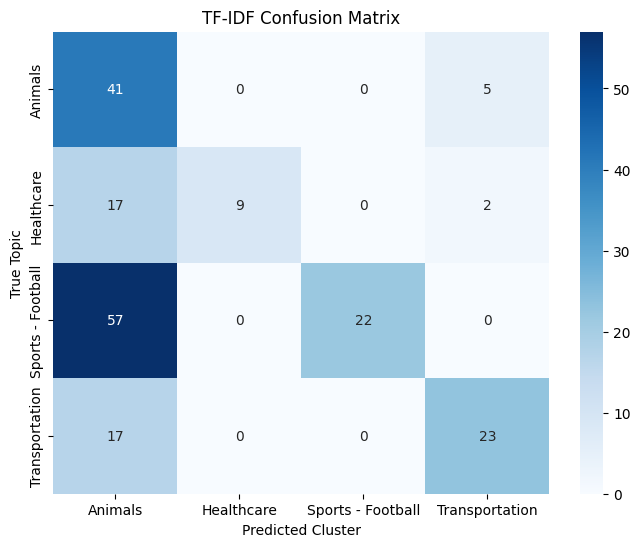

In [302]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_tfidf_df_aligned, annot=True, fmt="d", cmap="Blues")
plt.title("TF-IDF Confusion Matrix")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Topic")
plt.show()

### Topic Overview Table - TF-IDF

In [303]:
feature = tfidf_vectorizer.get_feature_names_out()

for t in top_topics:
    cluster_docs = X_tfidf[tfidf_clusters_aligned == t]
    mean_scores = np.asarray(cluster_docs.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[::-1][:10]
    top_words = [(feature[i]) for i in top_indices]
    print(f"\nTopic {t} [{le.classes_[t]}]: {top_words}")


Topic 0 [Animals]: ['coach', 'nfl', 'playoff', 'nation', 'largest', 'michigan', 'ever', 'titl', 'world', 'chang']

Topic 1 [Healthcare]: ['austin', 'hospit', 'defens', 'complic', 'cancer', 'kept', 'secret', 'biden', 'pentagon', 'secretari']

Topic 2 [Sports - Football]: ['super', 'bowl', 'chief', '49er', 'game', 'mahom', 'lion', 'bill', 'patriot', 'raven']

Topic 3 [Transportation]: ['plane', 'jet', 'american', 'boe', 'airlin', 'investig', 'newest', 'join', 'littl', 'smile']


### Embeddings Confusion Matrix

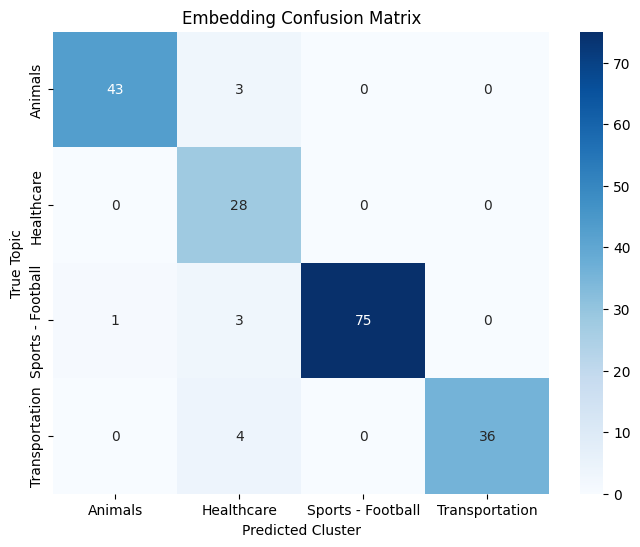

In [304]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_embed_df_aligned, annot=True, fmt="d", cmap="Blues")
plt.title("Embedding Confusion Matrix")
plt.xlabel("Predicted Cluster")
plt.ylabel("True Topic")
plt.show()

### Overview Score Table

In [306]:
# f1 = 2 * precision * recall / precision + recall

# get precision, recall, accuracy, f1-score for each cluster
print("TF-IDF Clustering Performance:")
print(classification_report(true_labels_encoded, tfidf_clusters_aligned, target_names=le.classes_))
print("Embeddings Clustering Performance:")
print(classification_report(true_labels_encoded, embed_clusters_aligned, target_names=le.classes_))

TF-IDF Clustering Performance:
                   precision    recall  f1-score   support

          Animals       0.31      0.89      0.46        46
       Healthcare       1.00      0.32      0.49        28
Sports - Football       1.00      0.28      0.44        79
   Transportation       0.77      0.57      0.66        40

         accuracy                           0.49       193
        macro avg       0.77      0.52      0.51       193
     weighted avg       0.79      0.49      0.49       193

Embeddings Clustering Performance:
                   precision    recall  f1-score   support

          Animals       0.98      0.93      0.96        46
       Healthcare       0.74      1.00      0.85        28
Sports - Football       1.00      0.95      0.97        79
   Transportation       1.00      0.90      0.95        40

         accuracy                           0.94       193
        macro avg       0.93      0.95      0.93       193
     weighted avg       0.96      0.94      